# Bird Species Image Classification

**Goal:** Build a model that looks at a photo of a bird and predicts which species it is.

**Dataset:** The dataset is organized in folders, where each folder name is the bird species and it
contains images of that species. Example structure:

```
Bird Speciees Dataset/
    AMERICAN GOLDFINCH/
        img1.jpg
        img2.jpg
        ...
    BARN OWL/
        ...
    CARMINE BEE-EATER/
        ...
    DOWNY WOODPECKER/
        ...
    EMPEROR PENGUIN/
        ...
    FLAMINGO/
        ...
```

**Approach:** Because we only have a limited number of images per species, training a Convolutional
Neural Network (CNN) completely from scratch would need a *huge* amount of data to get good accuracy.
Instead we will use **Transfer Learning**.

Transfer learning means we take a model (`MobileNetV2`) that has already been trained on a massive
dataset of 1.4 million images (ImageNet, which already includes many bird photos) and re-use what it
already learned about edges, textures, feathers, shapes, colors, etc. We then just teach it to
recognize *our* specific bird species. This works very well even with a small dataset and trains much
faster than a model built from zero.

This notebook is written step by step and kept beginner-friendly on purpose. Every cell has a short
explanation above it and comments inside the code.

## Step 1: Import the Libraries

We import all the tools we need:

- `os` and `pathlib` — to work with folders and file paths.
- `numpy` — for working with numbers/arrays.
- `matplotlib.pyplot` — for plotting images and graphs.
- `tensorflow` / `keras` — the deep learning library we will use to build and train the model.

In [2]:
# Basic Python tools for handling files and folders
import os
from pathlib import Path

# Numerical operations
import numpy as np

# For plotting images and graphs
import matplotlib.pyplot as plt

# Deep learning library
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Just to check everything installed correctly and see which TensorFlow version we have
print("TensorFlow version:", tf.__version__)
print(tf.config.list_physical_devices('GPU'))

# If a GPU is available, let TensorFlow grow memory usage as needed instead of grabbing all VRAM up front.
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

I0000 00:00:1784975459.997001   23407 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784975462.792110   23407 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784975499.687302   23407 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## GPU Check

Run the next cell to confirm TensorFlow can see your GPU before training starts.

In [3]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPUs detected:", gpus)

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU memory growth enabled.")
else:
    print("No GPU detected. TensorFlow will run on CPU.")

TensorFlow version: 2.21.0
GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU memory growth enabled.


## Step 2: Set the Dataset Path and Basic Parameters

Here we tell the notebook where the dataset folder is located on your computer, and we set some
basic settings (called "hyperparameters") that we will reuse later:

- `IMG_HEIGHT`, `IMG_WIDTH` — the size we will resize every image to before feeding it to the model.
  MobileNetV2 was originally trained on 224x224 images, so we use the same size.
- `BATCH_SIZE` — how many images the model looks at together in one training step.
- `EPOCHS` — how many times the model will go through the entire training dataset.

**Important:** Change `DATASET_DIR` below to match the exact path on your computer if it is different.

In [4]:
# Path to the main dataset folder (the one that contains one sub-folder per bird species).
# Update this path if your folder is located somewhere else.
DATASET_DIR = Path(r"/home/asus/projects/computer_vision/Bird species image classification/Bird Speciees Dataset")

# Image size that we will resize all pictures to (MobileNetV2 expects 224x224 images)
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)

# How many images are shown to the model at once during training
BATCH_SIZE = 32

# How many times the model will see the whole dataset during training
EPOCHS = 15

# Percentage of images set aside for validation (used to check performance during training)
VALIDATION_SPLIT = 0.2

# A fixed random seed so that results are reproducible (same split every time we run the notebook)
SEED = 42

## Step 3: Explore the Dataset

Before building any model, it's good practice to look at the data first:

- How many bird species (classes) are there?
- How many images does each species have?

This helps us spot problems early, for example a class with very few images, or a class with way
more images than the others (this is called **class imbalance**).

In [5]:
# Get the list of class (bird species) folder names automatically.
# Each folder inside DATASET_DIR represents one class/species.
class_names = sorted([folder.name for folder in DATASET_DIR.iterdir() if folder.is_dir()])

print("Number of bird species (classes) found:", len(class_names))
print("Class names:")
for name in class_names:
    print(" -", name)

Number of bird species (classes) found: 6
Class names:
 - AMERICAN GOLDFINCH
 - BARN OWL
 - CARMINE BEE-EATER
 - DOWNY WOODPECKER
 - EMPEROR PENGUIN
 - FLAMINGO


In [6]:
# Count how many images are inside each class folder
image_counts = {}

for class_name in class_names:
    class_folder = DATASET_DIR / class_name
    # Count only common image file types
    num_images = len([
        f for f in class_folder.iterdir()
        if f.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ])
    image_counts[class_name] = num_images

# Print how many images are in each folder
print("Number of images per species:")
for class_name, count in image_counts.items():
    print(f" - {class_name}: {count} images")

print("\nTotal images:", sum(image_counts.values()))

Number of images per species:
 - AMERICAN GOLDFINCH: 143 images
 - BARN OWL: 129 images
 - CARMINE BEE-EATER: 131 images
 - DOWNY WOODPECKER: 137 images
 - EMPEROR PENGUIN: 139 images
 - FLAMINGO: 132 images

Total images: 811


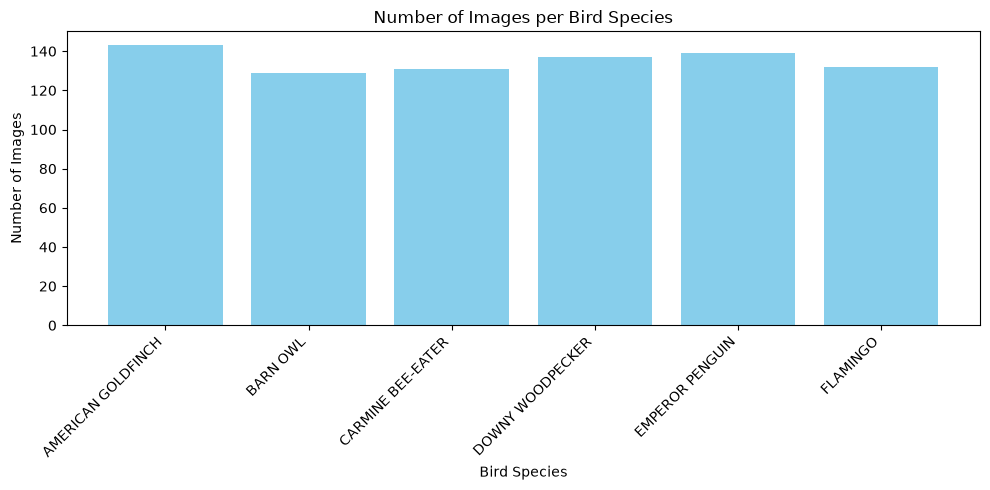

In [7]:
# Visualize the number of images per class as a bar chart.
# This makes it easy to spot if any class has too few or too many images (class imbalance).
plt.figure(figsize=(10, 5))
plt.bar(image_counts.keys(), image_counts.values(), color="skyblue")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Bird Species")
plt.ylabel("Number of Images")
plt.title("Number of Images per Bird Species")
plt.tight_layout()
plt.show()

## Step 4: Visualize Sample Images

Let's actually look at a few sample images from different classes, just to make sure the images
loaded correctly and to get a feel for the dataset (image quality, background, angle, etc.).

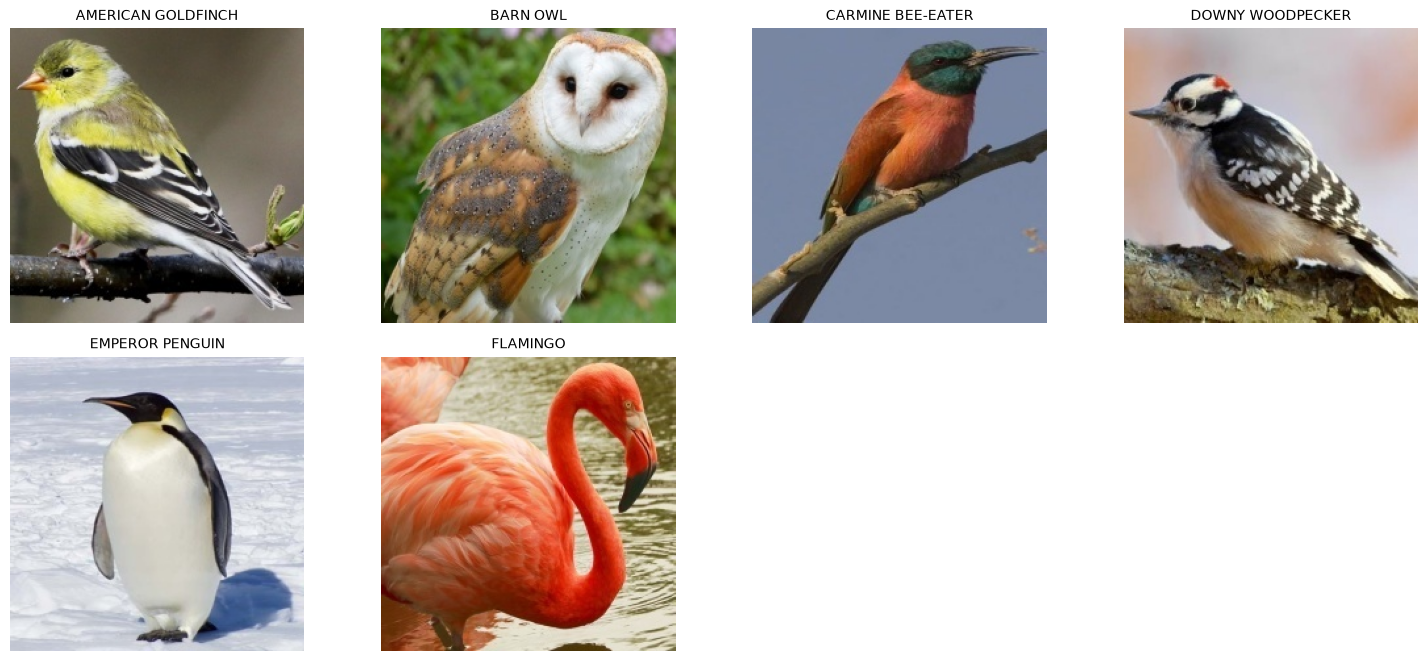

In [8]:
# Show one example image from each class in a grid
plt.figure(figsize=(15, 10))

for i, class_name in enumerate(class_names):
    class_folder = DATASET_DIR / class_name

    # Get the first image file found in this class folder
    image_files = [f for f in class_folder.iterdir() if f.suffix.lower() in [".jpg", ".jpeg", ".png"]]
    if len(image_files) == 0:
        continue
    sample_image_path = image_files[0]

    # Load and display the image
    img = keras.preprocessing.image.load_img(sample_image_path)
    plt.subplot(3, 4, i + 1)  # Adjust grid size (rows, cols) if you have more/fewer classes
    plt.imshow(img)
    plt.title(class_name, fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 5: Prepare the Data for Training

Neural networks work best when pixel values are small numbers (between 0 and 1) instead of the
usual 0-255 range, so we **rescale** the images.

We also use **data augmentation** on the training images. This means we randomly rotate, zoom,
flip, and shift the training images a little bit every time they are used. This artificially creates
more variety in the training data and helps the model generalize better (it prevents it from just
memorizing the exact training images, which is called **overfitting**).

We do **not** augment the validation images — we want to test on the real, unmodified pictures.

`ImageDataGenerator` also handles splitting the data into a training set and a validation set for us,
and `flow_from_directory` automatically reads the images from the folders and assigns labels based on
the folder names.

In [9]:
# ImageDataGenerator for the TRAINING data.
# rescale=1./255 converts pixel values from [0, 255] to [0, 1]
# The other parameters randomly modify the images slightly (data augmentation)
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,          # randomly rotate images by up to 20 degrees
    width_shift_range=0.1,      # randomly shift images horizontally
    height_shift_range=0.1,     # randomly shift images vertically
    zoom_range=0.1,              # randomly zoom into images
    horizontal_flip=True,        # randomly flip images left-right
    validation_split=VALIDATION_SPLIT  # reserve part of the data for validation
)

# ImageDataGenerator for VALIDATION data — only rescaling, no augmentation.
# We use the same validation_split value so it picks the matching "other half" of the data.
val_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=VALIDATION_SPLIT
)

In [10]:
# This automatically finds all images inside DATASET_DIR, resizes them, and assigns labels
# based on their folder name. subset="training" picks 80% of the data for training.
train_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",   # because we have more than 2 classes
    subset="training",
    seed=SEED
)

# subset="validation" picks the remaining 20% of the data for validation.
validation_generator = val_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    seed=SEED
)

# This dictionary maps class names to the numeric index the model will use internally
print("Class indices used by the model:", train_generator.class_indices)

Found 652 images belonging to 6 classes.


Found 159 images belonging to 6 classes.
Class indices used by the model: {'AMERICAN GOLDFINCH': 0, 'BARN OWL': 1, 'CARMINE BEE-EATER': 2, 'DOWNY WOODPECKER': 3, 'EMPEROR PENGUIN': 4, 'FLAMINGO': 5}


## Step 6: Build the Model Using Transfer Learning (MobileNetV2)

We load `MobileNetV2` with weights already trained on ImageNet, but **without** its original final
classification layer (`include_top=False`), because that layer was trained to recognize the original
1000 ImageNet categories, not our bird species.

We **freeze** all of MobileNetV2's layers (`layer.trainable = False`), which means their learned
weights will not change during training. We only train the small set of new layers we add on top.
This is faster and works well when we don't have a huge dataset.

On top of MobileNetV2 we add:
1. `GlobalAveragePooling2D` — shrinks each feature map down to a single number, reducing the size of
   the data while keeping the most important information.
2. `Dense` layer — a regular fully-connected layer that learns to combine those features.
3. `Dropout` — randomly "turns off" some neurons during training to reduce overfitting.
4. Final `Dense` layer — outputs one probability per bird species, using the `softmax` activation
   function so all probabilities add up to 1.

In [11]:
# Load MobileNetV2, pre-trained on ImageNet, without its original top classification layer
base_model = MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),  # 3 = RGB color channels
    include_top=False,                        # remove the original 1000-class output layer
    weights="imagenet"                        # use the pre-trained ImageNet weights
)

# Freeze the base model so its already-learned weights are not changed during training
base_model.trainable = False

print("Number of layers in the base model:", len(base_model.layers))

I0000 00:00:1784975531.678876   23407 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1763 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Number of layers in the base model: 154


In [12]:
# Build our own classification head on top of the frozen base model
x = base_model.output
x = GlobalAveragePooling2D()(x)      # reduce each feature map to a single average value
x = Dense(128, activation="relu")(x)  # a normal hidden layer with 128 neurons
x = Dropout(0.3)(x)                   # randomly drop 30% of neurons during training to fight overfitting

# Final output layer: one neuron per bird species, softmax turns outputs into probabilities
num_classes = len(class_names)
predictions = Dense(num_classes, activation="softmax")(x)

# Combine the base model and our new layers into one final model
model = Model(inputs=base_model.input, outputs=predictions)

## Step 7: Compile the Model

Before training, we need to configure how the model will learn:

- **Optimizer (`adam`)** — the algorithm that updates the model's weights during training. Adam is a
  popular, reliable default choice.
- **Loss function (`categorical_crossentropy`)** — measures how wrong the model's predictions are.
  This is the standard choice for multi-class classification problems like ours.
- **Metrics (`accuracy`)** — what we want to monitor while training, in this case the percentage of
  correctly classified images.

In [13]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Print a summary of the model: layers, output shapes, and number of trainable parameters
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Step 8: Set Up Training Callbacks

Callbacks are helper tools that run automatically during training:

- **EarlyStopping** — stops training automatically if the validation accuracy stops improving for a
  few epochs in a row. This saves time and helps prevent overfitting.
- **ModelCheckpoint** — automatically saves the best version of the model (the one with the highest
  validation accuracy) to a file as training goes on.

In [14]:
# Stop training early if validation loss doesn't improve for 3 epochs in a row,
# and automatically restore the best weights found during training.
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Save the best model (based on validation accuracy) to a file as we train
checkpoint = ModelCheckpoint(
    "best_bird_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

## Step 9: Train the Model

Now we actually train the model using our training and validation data generators. This step can
take a while depending on your computer's hardware (it will be much faster if you have a GPU).

In [15]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/15


I0000 00:00:1784975551.105054   23407 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1784975563.951584   23814 service.cc:153] XLA service 0x731f88033570 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784975563.951637   23814 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 13.3.0; Runtime: 12.5.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1784975564.251734   23814 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1784975566.256249   23814 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1784975566.437097   23814 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8082__.123
W0000 00:00:1784975587.496052   23814 bfc_allocator.cc:383] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-al

16/21 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.8242 - loss: 0.5965  

I0000 00:00:1784975616.346703   23814 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8082__.123


21/21 ━━━━━━━━━━━━━━━━━━━━ 100s 3s/step - accuracy: 0.8558 - loss: 0.4850 - val_accuracy: 1.0000 - val_loss: 0.0173
Epoch 2/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 588ms/step - accuracy: 0.9939 - loss: 0.0272 - val_accuracy: 1.0000 - val_loss: 0.0052
Epoch 3/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 510ms/step - accuracy: 1.0000 - loss: 0.0085 - val_accuracy: 1.0000 - val_loss: 0.0042
Epoch 4/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 615ms/step - accuracy: 0.9969 - loss: 0.0168 - val_accuracy: 1.0000 - val_loss: 0.0019
Epoch 5/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 533ms/step - accuracy: 0.9954 - loss: 0.0113 - val_accuracy: 1.0000 - val_loss: 0.0016
Epoch 6/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 544ms/step - accuracy: 1.0000 - loss: 0.0045 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 7/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 546ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 8/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 542ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 1.0000 

## Step 10: Plot the Training History

It's useful to visualize how accuracy and loss changed over each epoch, for both the training and
validation data. This helps us see:

- If the model is actually learning (accuracy going up, loss going down).
- If the model is **overfitting** — this shows up as training accuracy continuing to improve while
  validation accuracy stalls or gets worse.

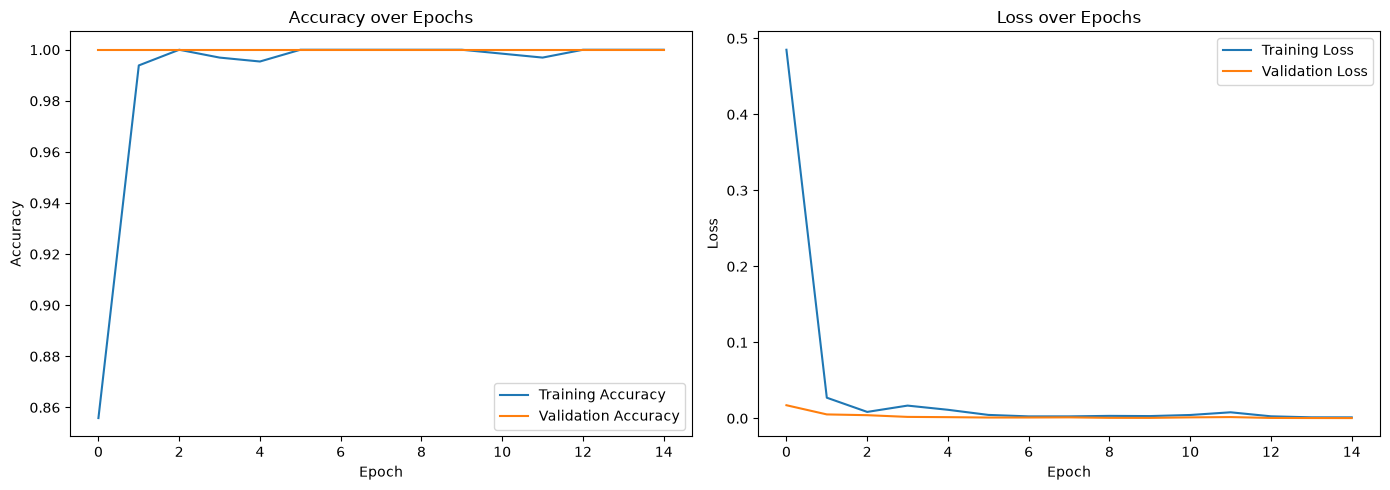

In [16]:
# Plot training vs validation accuracy and loss side by side
plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Step 11: Evaluate the Model

Finally, let's check the model's overall accuracy and loss on the validation set, which gives us a
single, clear number to describe how well the model performs.

In [17]:
val_loss, val_accuracy = model.evaluate(validation_generator)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f} ({val_accuracy * 100:.2f}%)")

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step - accuracy: 1.0000 - loss: 3.5467e-04
Validation Loss: 0.0004
Validation Accuracy: 1.0000 (100.00%)


## Step 12: Test the Model on Some Sample Images

Let's pick a batch of validation images and see what the model predicts for each one, comparing it
to the true label. This is a good final "sanity check" to see the model in action.

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


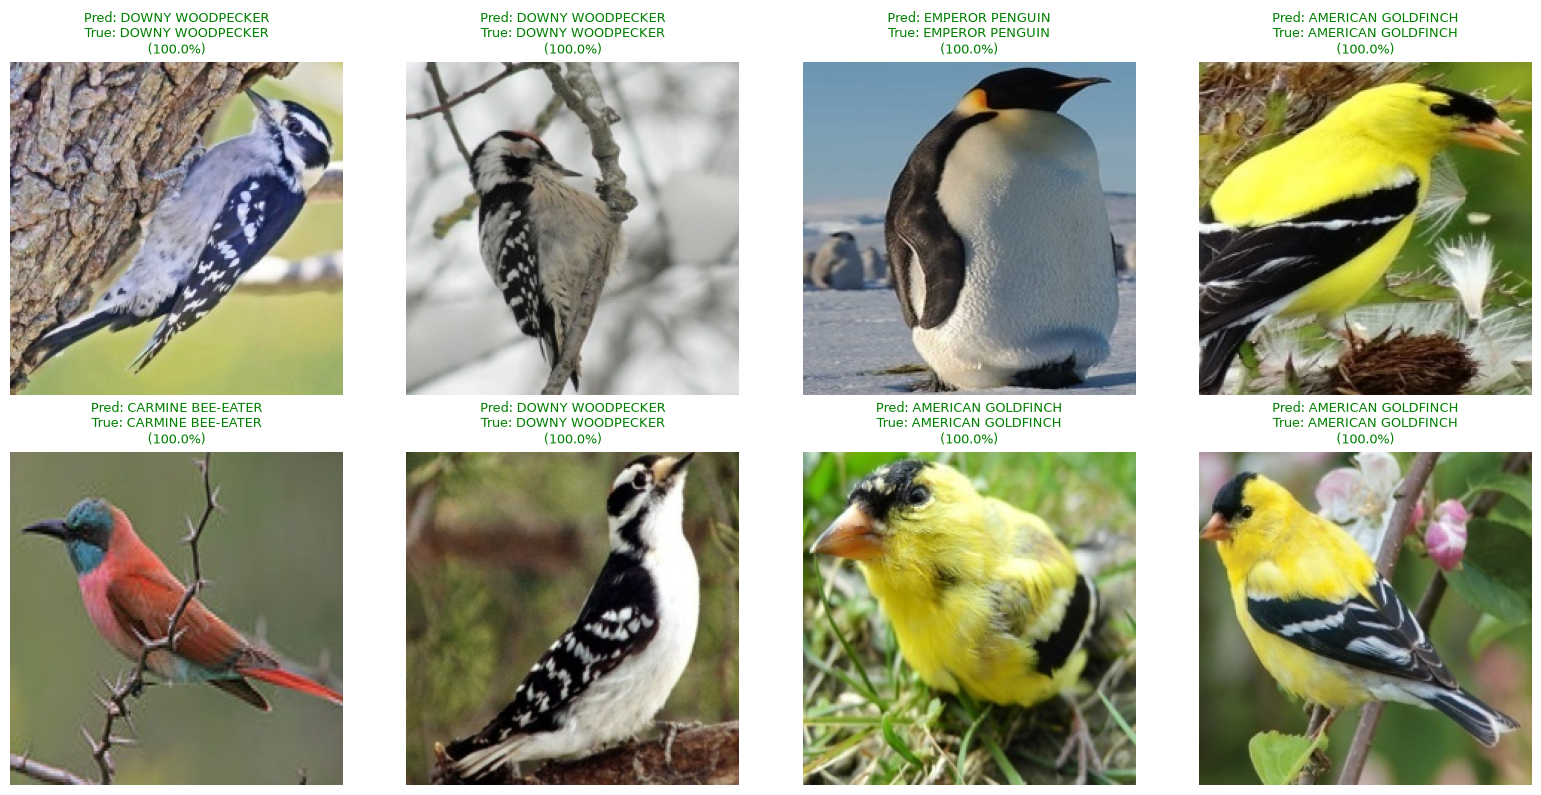

In [18]:
# Get one batch of images and their true labels from the validation generator
sample_images, sample_labels = next(validation_generator)

# Get the model's predictions for this batch
predictions = model.predict(sample_images)

# Map numeric class indices back to species names
index_to_class = {v: k for k, v in train_generator.class_indices.items()}

# Display up to 8 sample predictions
plt.figure(figsize=(16, 8))
num_to_show = min(8, len(sample_images))

for i in range(num_to_show):
    plt.subplot(2, 4, i + 1)
    plt.imshow(sample_images[i])

    predicted_class = index_to_class[np.argmax(predictions[i])]
    true_class = index_to_class[np.argmax(sample_labels[i])]
    confidence = np.max(predictions[i]) * 100

    # Green title if correct, red if wrong
    color = "green" if predicted_class == true_class else "red"
    plt.title(f"Pred: {predicted_class}\nTrue: {true_class}\n({confidence:.1f}%)",
              color=color, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 13: Save the Final Model

We save the trained model to a file so we can reuse it later without having to train it again.
(Note: `ModelCheckpoint` already saved the *best* version during training as `best_bird_model.keras`;
this step saves the *final* state of the model after training finished.)

In [19]:
model.save("bird_species_classifier.keras")
print("Model saved as bird_species_classifier.keras")

Model saved as bird_species_classifier.keras


## Next Steps / Ideas to Improve the Model (Optional)

This notebook covers a solid, beginner-friendly baseline. If you want to improve accuracy further,
here are a few ideas to explore later:

- **Fine-tuning**: unfreeze the last few layers of MobileNetV2 and train them with a very small
  learning rate, so the model adapts its high-level features specifically to birds.
- **More data**: add more images per species, especially for any class that had very few images.
- **Try a different base model**: e.g. `EfficientNetB0` or `ResNet50` instead of `MobileNetV2`.
- **Confusion matrix**: build a full confusion matrix to see exactly which species get confused with
  each other.